### These: 
#### Länder mit höherem BIP pro Kopf haben eine höhere Lebenserwartung. Dargestellt in einem direkten Vergleich von jeweils 2 Ländern mit unterschiedlichem BIP pro Kopf und ähnlicher Einwohnerzahl

In [108]:
#Wichtige Imports
import pandas as pd
import matplotlib.pyplot as plt
import re

In [ ]:
import pandas as pd
import re

# Load WHO mortality data
df = pd.read_csv("Data_Files/country_lookup.csv")

# Keep only the columns we really need
df = df[["Country", "Year", "Cause", "Deaths1"]]

# Check how big the data is
print("Rows:", len(df))
print("Columns:", df.columns.tolist())

# Look at a few examples
print(df.head())


In [ ]:
# Define the list of countries you want
countries = [
    "Switzerland", "Portugal", "Republic of Korea", "Colombia",
    "Canada", "Poland", "Sweden", "Romania", "Japan", "Mexico"
]

# Define which years to include
years = list(range(2007, 2023))

# Filter the DataFrame
df = df[df["Country"].isin(countries) & df["Year"].isin(years)].copy()

print("After filtering:", len(df), "rows left")


In [ ]:
# Remove rows where the cause is missing or looks fake (AAA, BBB, etc.)
invalid_codes = [
    "AAA","BBB","CCC","DDD","EEE","FFF","GGG","HHH","III","JJJ","KKK",
    "LLL","MMM","NNN","OOO","PPP","QQQ","RRR","SSS","TTT","UUU","VVV",
    "WWW","XXX","YYY","ZZZ"
]

df = df[~df["Cause"].isin(invalid_codes)]

# Remove codes that start with R or Z (these are ill-defined or admin codes)
df = df[~df["Cause"].str.startswith(("R", "Z"), na=False)]

print("After cleaning:", len(df), "rows left")


In [ ]:
def categorize_icd10(code):
    """Turn an ICD-10 code into a broad WHO category."""
    if not isinstance(code, str):
        return "Other/Unclassified"

    c = code.strip().upper()
    c = re.sub(r"[^A-Z0-9]", "", c)  # remove extra characters

    if re.match(r"^[AB]", c):
        return "Communicable Diseases"
    elif re.match(r"^[CDEFGHIJKLMN]", c):
        return "Noncommunicable Diseases"
    elif re.match(r"^[OPQ]", c):
        return "Perinatal & Congenital Conditions"
    elif re.match(r"^[RSTVWXY]", c):
        return "Injuries & External Causes"
    elif re.match(r"^[U]", c):
        return "Communicable Diseases"
    else:
        return "Other/Unclassified"


In [ ]:
df["Category"] = df["Cause"].apply(categorize_icd10)

print("Sample of categorized data:")
print(df.sample(5))


In [ ]:
# Add up all deaths within each category for each country and year
df_grouped = (
    df.groupby(["Country", "Year", "Category"], as_index=False)["Deaths1"].sum()
)

# Calculate percentage share inside each country-year
df_grouped["Percent"] = (
    df_grouped["Deaths1"] /
    df_grouped.groupby(["Country", "Year"])["Deaths1"].transform("sum") * 100
)


In [ ]:
swiss_2019 = (
    df_grouped[(df_grouped["Country"] == "Switzerland") & (df_grouped["Year"] == 2019)]
    .sort_values("Percent", ascending=False)
)
print(swiss_2019)


In [ ]:
df_grouped.to_csv("WHO_clean_summary.csv", index=False)
print("Saved to WHO_clean_summary.csv")


Daten rauslesen für Portugal

In [109]:
import pandas as pd

# Load WHO dataset
df = pd.read_csv("Data_Files/base_data104_with_lookup.csv")

# Define countries to analyze
countries = [
    "Switzerland", "Portugal",
    "Republic of Korea", "Colombia",
    "Canada", "Poland",
    "Sweden", "Romania",
    "Japan", "Mexico"
]

# Count entries per year for each country
counts_dict = {}

for country in countries:
    counts = df[df["Country"] == country].groupby("Year").size()
    counts_dict[country] = counts

# Combine all countries side-by-side
comparison_all = pd.concat(counts_dict, axis=1)

# Replace missing values with 0 and cast to int
comparison_all = comparison_all.fillna(0).astype(int)

print("Vergleich der Einträge pro Jahr für ausgewählte Länder:")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
display(comparison_all)


Vergleich der Einträge pro Jahr für ausgewählte Länder:


,Switzerland,Portugal,Republic of Korea,Colombia,Canada,Poland,Sweden,Romania,Japan,Mexico
Year,,,,,,,,,,
1995,2880,0,0,0,0,0,0,0,5456,0
1996,2809,0,0,0,0,0,0,0,5363,0
1997,2604,0,3550,4441,0,0,0,0,5306,0
1998,2707,0,3694,4532,0,0,0,0,5329,6287
1999,2679,0,3668,4493,0,4649,2579,3688,5434,6067
2000,2663,0,3989,4539,3845,4585,2575,3484,5390,5924
2001,2722,0,4021,4730,3796,4519,2509,3348,5275,5870
2002,2619,2652,4402,4680,3718,4425,2574,3283,5255,5847
2003,2696,2579,4330,4723,3731,4415,2536,3379,5349,5926


Years with full data across all countries: Index([2002, 2003, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
       2017, 2018, 2019],
      dtype='int64', name='Year')


<Axes: >

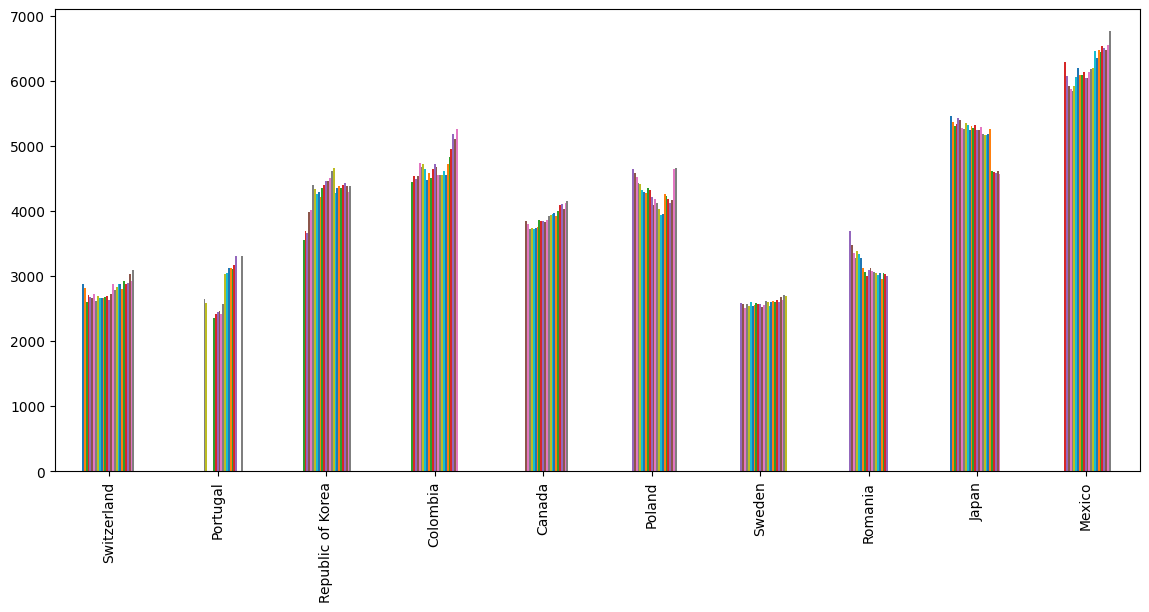

In [110]:
sorted(df["Country"].unique())

common_years = comparison_all[(comparison_all > 0).all(axis=1)].index
print("Years with full data across all countries:", common_years)
# Identify years with full data across all countries

comparison_all.T.plot(kind="bar", figsize=(14,6), legend=False)



In [111]:
import pandas as pd

# Years to include
years = [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]

# Your country pairs (similar population, different GDP)
country_pairs = [
    ("Switzerland", "Portugal"),
    ("Republic of Korea", "Colombia"),
    ("Japan", "Mexico")
]

death_col = "Deaths1"

# Filter dataset for relevant years only
df_years = df[df["Year"].isin(years)].copy()

results = []

for country_a, country_b in country_pairs:
    # Keep only the two countries in the pair
    pair_df = df_years[df_years["Country"].isin([country_a, country_b])]

    # Count duplicates across both countries combined
    dup_count = pair_df.duplicated(subset=["Country", "Cause", "Sex"], keep=False).sum()

    # Count total rows (for context)
    total_rows = len(pair_df)

    results.append({
        "Pair": f"{country_a} vs {country_b}",
        "Years": f"{years[0]}–{years[-1]}",
        "Duplicates": dup_count,
        "Total Rows": total_rows,
        "Share (%)": round(dup_count / total_rows * 100, 2)
    })

# Turn into DataFrame for easy viewing
dup_summary = pd.DataFrame(results)
print(dup_summary)


                            Pair      Years  Duplicates  Total Rows  Share (%)
0        Switzerland vs Portugal  2007–2019       70283       73053      96.21
1  Republic of Korea vs Colombia  2007–2019      115916      118683      97.67
2                Japan vs Mexico  2007–2019      144795      147680      98.05


In [112]:
import pandas as pd

# Load WHO dataset
df = pd.read_csv("Data_Files/country_lookup.csv")

# Define years and countries
years = list(range(2007, 2023))  # 2007–2019 inclusive
countries = [
    "Switzerland", "Portugal",
    "Republic of Korea", "Colombia",
    "Canada", "Poland",
    "Sweden", "Romania",
    "Japan", "Mexico"
]

death_col = "Deaths1"

#Filter dataset
df_sub = df[df["Country"].isin(countries) & df["Year"].isin(years)].copy()

#Deduplicate per Country–Year–Cause–Sex, keep highest total (avoid double-counting)
df_unique = (
    df_sub
    .groupby(["Country", "Year", "Cause", "Sex"], as_index=False)[death_col]
    .max()
)

#Combine male + female totals to get total deaths per cause
df_total = (
    df_unique
    .groupby(["Country", "Year", "Cause"], as_index=False)[death_col]
    .sum()
)

# #Example: show the top 10 causes by total deaths per country in 2019
# year = 2022
# for c in countries:
#     print(f"\nTop 10 causes of death in {c} ({year}):")
#     top10 = (
#         df_total[(df_total["Country"] == c) & (df_total["Year"] == year)]
#         .sort_values(death_col, ascending=False)
#         .head(10)
#     )
#     print(top10.to_string(index=False))



Um zwischen Ländern mit höherem und mittlerem Einkommen zu unterscheiden, werden wir die Einkommensklassifikation der Weltbank verwenden. Dort werden die Schweiz, Japan, Portugal, Kanada, Schweden und Süd Korea (Republik Korea) als High-Income Länder eingestuft, während Polen, Rumänien, Mexico und Kolumbien zu den Middle-Income Länder zählen.

Quelle: https://datahelpdesk.worldbank.org/knowledgebase/articles/906519

In [131]:
def categorize_icd10(code):
    if not isinstance(code, str) or len(code) < 3:
        return "Other/Unclassified"

    code = code.strip().upper()
    letter = code[0]

    # Try to extract the numeric part
    try:
        number = int(code[1:3])
    except ValueError:
        return "Other/Unclassified"

    # --- Communicable Diseases ---
    if letter in ["A", "B"] or letter in ["O", "P"] or letter == "U":
        return "Communicable Diseases"

    # --- Noncommunicable Diseases ---
    if letter in ["C", "D"] and number <= 89:
        return "Noncommunicable Diseases"
    if letter in ["E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "Q"]:
        return "Noncommunicable Diseases"

    # --- Injuries ---
    if letter in ["S", "T", "V", "W", "X", "Y"]:
        return "Injuries"

    # --- Other/Unclassified ---
    if letter in ["R", "Z"]:
        return "Other/Unclassified"

    return "Other/Unclassified"


In [142]:
import pandas as pd
import re

# ------------------------------------------------------------
# STEP 1 — Load and subset the data
# ------------------------------------------------------------
df = pd.read_csv("Data_Files/country_lookup.csv")

countries = [
    "Switzerland", "Portugal", "Republic of Korea", "Colombia",
    "Canada", "Poland", "Sweden", "Romania", "Japan", "Mexico"
]
years = list(range(2007, 2023))

df_sub = df[df["Country"].isin(countries) & df["Year"].isin(years)].copy()
df_sub = df_sub[["Country", "Year", "Cause", "Deaths1"]]  # keep relevant cols

print("🧩 Step 1 — Data loaded")
print(f"Shape: {df_sub.shape}")
print(f"Unique countries: {df_sub['Country'].nunique()}")
print(f"Unique years: {df_sub['Year'].nunique()}")
print("Sample causes:\n", df_sub["Cause"].unique()[:20], "\n")


# ------------------------------------------------------------
# STEP 2 — Define categorization function
# ------------------------------------------------------------
def categorize_icd10(code: str) -> str:
    """Return high-level ICD-10 category."""
    if not isinstance(code, str) or len(code) < 1:
        return "Other/Unclassified"

    c = code.strip().upper()

    # Defensive: remove trailing non-alphanumeric chars
    c = re.sub(r"[^A-Z0-9]", "", c)

    if re.match(r"^A|^B", c):
        return "Communicable Diseases"
    elif re.match(r"^C|^D", c):
        return "Noncommunicable Diseases"
    elif re.match(r"^E|^F|^G|^H|^I|^J|^K|^L|^M|^N", c):
        return "Noncommunicable Diseases"
    elif re.match(r"^O|^P|^Q", c):
        return "Noncommunicable Diseases"
    elif re.match(r"^R", c):
        return "Other/Unclassified"
    elif re.match(r"^S|^T|^V|^W|^X|^Y", c):
        return "Injuries"
    elif re.match(r"^Z", c):
        return "Other/Unclassified"
    elif re.match(r"^U", c):
        return "Communicable Diseases"  # includes emergency/new pathogens
    else:
        return "Other/Unclassified"


# ------------------------------------------------------------
# STEP 3 — Combine male/female deaths
# ------------------------------------------------------------
df_total = (
    df_sub.groupby(["Country", "Year", "Cause"], as_index=False)["Deaths1"].sum()
)

# ------------------------------------------------------------
# STEP 4 — Clean invalid/aggregate ICD codes
# ------------------------------------------------------------
invalid_codes = [
    "AAA", "BBB", "CCC", "DDD", "EEE", "FFF", "GGG", "HHH",
    "III", "JJJ", "KKK", "LLL", "MMM", "NNN", "OOO", "PPP",
    "QQQ", "RRR", "SSS", "TTT", "UUU", "VVV", "WWW", "XXX", "YYY", "ZZZ"
]

df_total = df_total[~df_total["Cause"].isin(invalid_codes)].copy()

# Remove rows with ill-defined or unclassified prefixes (R/Z)
df_total = df_total[~df_total["Cause"].str.startswith(("R", "Z"), na=False)].copy()

print(f"✅ Step 4 — After cleaning: {len(df_total)} rows remain")


# ------------------------------------------------------------
# STEP 5 — Categorize each ICD-10 cause
# ------------------------------------------------------------
df_total["Category"] = df_total["Cause"].apply(categorize_icd10)

print("\n🏷️ Step 5 — Category assignment sample:")
print(df_total.sample(10, random_state=42))


# ------------------------------------------------------------
# STEP 6 — Aggregate by Country–Year–Category
# ------------------------------------------------------------
df_grouped = (
    df_total.groupby(["Country", "Year", "Category"], as_index=False)["Deaths1"].sum()
)

df_grouped["Percent"] = (
    df_grouped["Deaths1"]
    / df_grouped.groupby(["Country", "Year"])["Deaths1"].transform("sum")
    * 100
)

# ------------------------------------------------------------
# STEP 7 — Debug check for Switzerland 2019
# ------------------------------------------------------------
print("\n📊 Step 7 — Switzerland 2019 breakdown:")
ch_2019 = (
    df_grouped[(df_grouped["Country"] == "Switzerland") & (df_grouped["Year"] == 2019)]
    .sort_values("Percent", ascending=False)
)
print(ch_2019.to_string(index=False))

# ------------------------------------------------------------
# STEP 8 — Weighted ICD first-letter check (death-weighted)
# ------------------------------------------------------------
df_sw = df_total[(df_total["Country"] == "Switzerland") & (df_total["Year"] == 2019)]
weighted_counts = (
    df_sw.assign(letter=df_sw["Cause"].str[0])
    .groupby("letter")["Deaths1"]
    .sum()
    .sort_values(ascending=False)
)
print("\n💀 Step 8 — Death-weighted ICD first letters for Switzerland 2019:")
print(weighted_counts.head(20))
print("\nShare (%):")
print((weighted_counts / weighted_counts.sum() * 100).round(2).head(20))

# ------------------------------------------------------------
# STEP 9 — Overall category distribution across dataset
# ------------------------------------------------------------
cat_dist = (
    df_grouped.groupby("Category")["Deaths1"]
    .sum()
    .pipe(lambda s: s / s.sum() * 100)
    .round(2)
)
print("\n🌍 Step 9 — Overall category distribution (% of all deaths):")
print(cat_dist)

# ------------------------------------------------------------
# Optional — save results
# ------------------------------------------------------------
df_grouped.to_csv("cleaned_country_category_summary.csv", index=False)
print("\n💾 Results saved → cleaned_country_category_summary.csv")


🧩 Step 1 — Data loaded
Shape: (616255, 4)
Unique countries: 10
Unique years: 16
Sample causes:
 ['A020' 'A021' 'A044' 'A045' 'A047' 'A048' 'A049' 'A073' 'A080' 'A081'
 'A084' 'A09' 'A162' 'A165' 'A169' 'A170' 'A178' 'A180' 'A188' 'A192'] 

✅ Step 4 — After cleaning: 380213 rows remain

🏷️ Step 5 — Category assignment sample:
            Country  Year Cause  Deaths1                  Category
360397  Switzerland  2009  C673        1  Noncommunicable Diseases
229175       Poland  2021  D609        5  Noncommunicable Diseases
160370       Mexico  2015  C411       26  Noncommunicable Diseases
349390       Sweden  2018  N133        7  Noncommunicable Diseases
94012         Japan  2010   C20    13874  Noncommunicable Diseases
223543       Poland  2019  C434       28  Noncommunicable Diseases
314518      Romania  2011  X828        1                  Injuries
172907       Mexico  2018   G09       79  Noncommunicable Diseases
161516       Mexico  2015  J348        2  Noncommunicable Diseases
266

In [139]:
print("\n🔍 Step 7b — What ICD letters appear in Switzerland 2019?")
ch_codes = df_total[df_total["Country"].eq("Switzerland") & df_total["Year"].eq(2019)]
print(ch_codes["Cause"].str[0].value_counts().sort_index())

print("\n📈 Step 9b — Total deaths per year for Switzerland:")
print(df_total[df_total["Country"] == "Switzerland"].groupby("Year")["Deaths1"].sum())





🔍 Step 7b — What ICD letters appear in Switzerland 2019?
Cause
A     50
B     51
C    293
D    116
E     91
F     76
G    108
H     13
I    205
J     88
K    178
L     28
M     93
N     62
O      5
P     47
Q     75
V     72
W     92
X     64
Y     44
Name: count, dtype: int64

📈 Step 9b — Total deaths per year for Switzerland:
Year
2007    120419
2008    120686
2009    122710
2010    123150
2011    121969
2012    125798
2013    127374
2014    125238
2015    132362
2016    127127
2017    131107
2018    131008
2019    131160
2020    148095
2021    138195
2022    144038
Name: Deaths1, dtype: int64


In [140]:
print("\n💀 Step 7c — Death-weighted ICD first letters for Switzerland 2019:")
weighted_counts = (
    df_total[df_total["Country"].eq("Switzerland") & df_total["Year"].eq(2019)]
    .assign(letter=df_total["Cause"].str[0])
    .groupby("letter")["Deaths1"].sum()
    .sort_values(ascending=False)
)
print(weighted_counts.head(20))
print("\nShare (%):")
print((weighted_counts / weighted_counts.sum() * 100).round(2).head(20))



💀 Step 7c — Death-weighted ICD first letters for Switzerland 2019:
letter
A    68267
I    19901
C    17191
F     5815
J     4561
G     3690
K     2616
W     1997
E     1739
X     1384
N     1252
D      796
M      660
B      327
Q      253
V      221
Y      175
P      160
L      118
H       31
Name: Deaths1, dtype: int64

Share (%):
letter
A    52.05
I    15.17
C    13.11
F     4.43
J     3.48
G     2.81
K     1.99
W     1.52
E     1.33
X     1.06
N     0.95
D     0.61
M     0.50
B     0.25
Q     0.19
V     0.17
Y     0.13
P     0.12
L     0.09
H     0.02
Name: Deaths1, dtype: float64


In [141]:
print(df_total[df_total["Country"].eq("Switzerland") & df_total["Year"].eq(2019)]["Cause"].unique()[:50])


['A010' 'A020' 'A021' 'A039' 'A044' 'A045' 'A047' 'A081' 'A084' 'A085'
 'A090' 'A099' 'A153' 'A162' 'A169' 'A199' 'A310' 'A319' 'A321' 'A327'
 'A390' 'A394' 'A399' 'A401' 'A402' 'A403' 'A408' 'A409' 'A410' 'A411'
 'A412' 'A413' 'A414' 'A415' 'A418' 'A419' 'A46' 'A481' 'A483' 'A490'
 'A491' 'A492' 'A498' 'A499' 'A692' 'A810' 'A812' 'A841' 'A86' 'AAA']


In [118]:
# Show 5 example rows
df_total.head(5).to_string()

# Show column names
print("\nColumns:\n", df_total.columns.tolist())

# Check a few unique cause codes
print("\nExample ICD codes:\n", df_total["Cause"].unique()[:15])



Columns:
 ['Country', 'Year', 'Cause', 'Deaths1', 'Category']

Example ICD codes:
 ['A020' 'A021' 'A044' 'A045' 'A047' 'A048' 'A049' 'A073' 'A080' 'A081'
 'A084' 'A09' 'A162' 'A165' 'A169']
